In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

# Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    benchmark_data = json.load(f)

print(f"Loaded {len(benchmark_data)} configurations")
print(f"Configurations: {[config['config_name'] for config in benchmark_data]}")


Loaded 7 configurations
Configurations: ['spacy', 'ai4privacy', 'edsnlp', 'spacy+ai4privacy', 'spacy+edsnlp', 'ai4privacy+edsnlp', 'all']


In [3]:
def prepare_data_for_plotting(benchmark_data, metric_type='entity_aware'):
    """
    Prepare data for plotting grouped bar charts.
    
    Returns:
        df: DataFrame with columns: entity_type, config_name, precision, recall, f1
    """
    rows = []
    for config in benchmark_data:
        config_name = config['config_name']
        metrics = config[metric_type]
        for metric in metrics:
            rows.append({
                'entity_type': metric['entity_type'],
                'config_name': config_name,
                'precision': metric['precision'],
                'recall': metric['recall'],
                'f1': metric['f1']
            })
    return pd.DataFrame(rows)

# Prepare data for both entity_aware and entity_unaware
df_aware = prepare_data_for_plotting(benchmark_data, 'entity_aware')
df_unaware = prepare_data_for_plotting(benchmark_data, 'entity_unaware')

print("Entity-aware data shape:", df_aware.shape)
print("Entity-unaware data shape:", df_unaware.shape)
print("\nEntity types:", sorted(df_aware['entity_type'].unique()))


Entity-aware data shape: (118, 5)
Entity-unaware data shape: (118, 5)

Entity types: ['AGE', 'CREDIT_CARD', 'DATE_TIME', 'DRIVERLICENSENUM', 'EMAIL_ADDRESS', 'GENDER', 'IBAN_CODE', 'IDCARDNUM', 'ID_CARD', 'IP_ADDRESS', 'LOCATION', 'ORGANIZATION', 'PASSPORTNUM', 'PERSON', 'PHONE_NUMBER', 'TAXNUM', 'URL', 'US_SSN']


In [13]:
entities_to_plot = ['AGE', 'CREDIT_CARD', 'DATE_TIME', 'DRIVERLICENSENUM', 'EMAIL_ADDRESS', 'GENDER', 'IDCARDNUM', 'LOCATION', 'PASSPORTNUM', 'PERSON', 'PHONE_NUMBER', 'TAXNUM']

def plot_metrics(df, title_prefix, figsize=(18, 6)):
    """
    Create 3 bar plots side by side for precision, recall, and F1.
    """
    # Get unique entity types and config names
    entity_types = entities_to_plot
    config_names = ["spacy", "ai4privacy", "edsnlp", "spacy+ai4privacy", "spacy+edsnlp", "ai4privacy+edsnlp", "all"]
    
    # Set up the figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(title_prefix, fontsize=16, fontweight='bold')
    
    metrics = ['precision', 'recall', 'f1']
    metric_labels = ['Precision', 'Recall', 'F1 Score']
    
    # Set up colors for each config
    colors = plt.cm.Set1(np.linspace(0, 1, len(config_names)))
    color_map = {config: colors[i] for i, config in enumerate(config_names)}
    
    # Width of bars
    x = np.arange(len(entity_types))
    width = 0.8 / len(config_names)
    
    for ax_idx, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[ax_idx]
        
        # Plot bars for each config
        for i, config_name in enumerate(config_names):
            values = []
            for entity_type in entity_types:
                value = df[(df['entity_type'] == entity_type) & 
                          (df['config_name'] == config_name)][metric].values
                values.append(value[0] if len(value) > 0 else 0)
            
            offset = (i - len(config_names) / 2 + 0.5) * width
            ax.bar(x + offset, values, width, label=config_name, 
                  color=color_map[config_name], alpha=0.8)
        
        ax.set_xlabel('Entity Type', fontsize=10)
        ax.set_ylabel(metric_label, fontsize=10)
        ax.set_title(metric_label, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(entity_types, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(fontsize=8, loc='upper left')
    
    plt.tight_layout()
    return fig


## Entity aware benchmark

- We compute entity aware metrics for each entity type `E`:
    - TP if detected class and ground truth are both `E`
    - FN ground truth is `E` and detected is different
    - FP detected is `E` and ground truth is different

Reminder:
$$
Precision = TP/(TP + FP)
$$
$$
Recall = TP/(TP + FN)
$$
$$
F1=2*(Precision*Recall)/(Precision + Recall)
$$

In our case for privacy masking, we will be mainly optimizing recall.

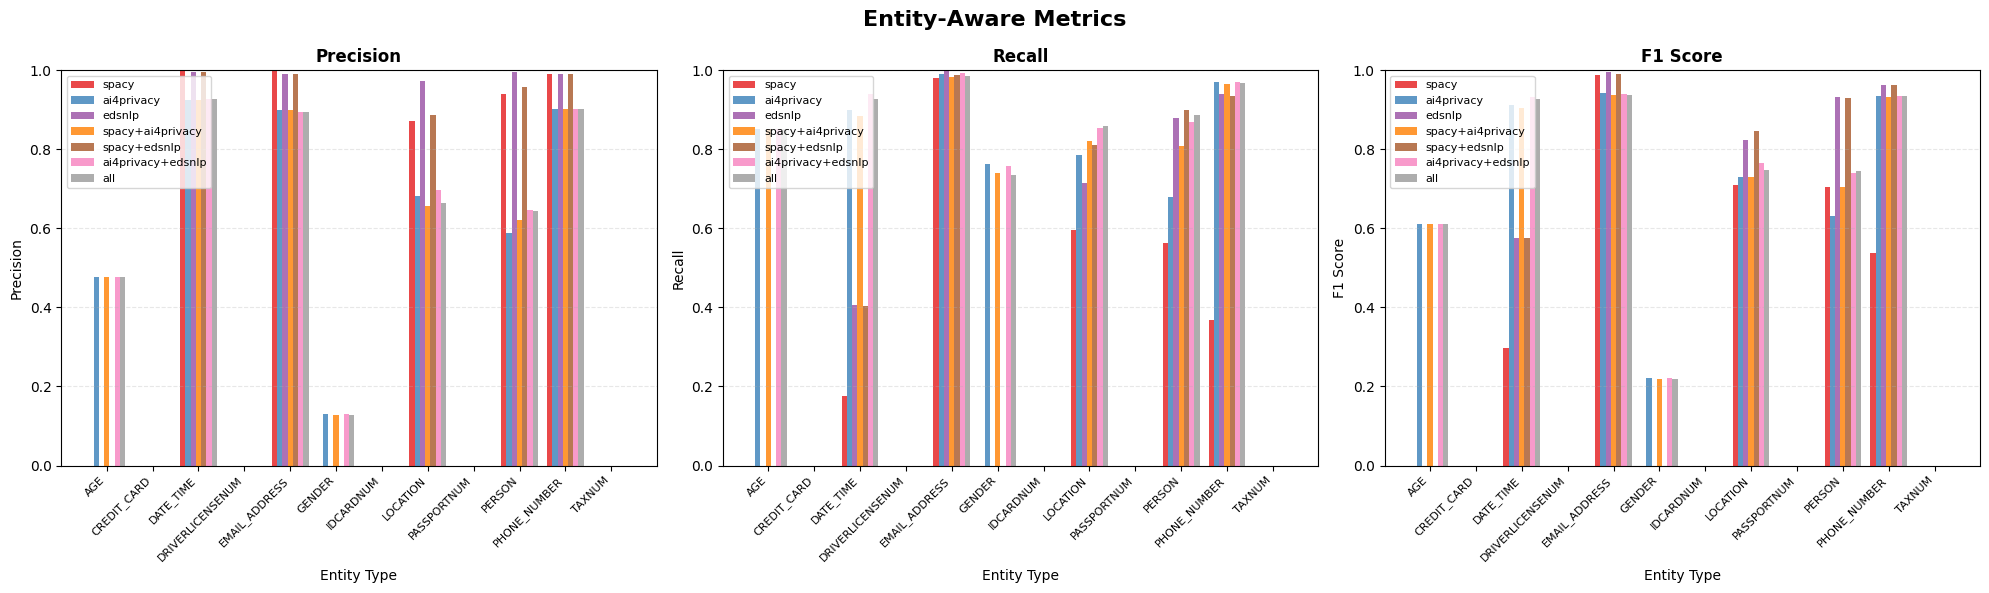

In [14]:
# Plot entity-aware metrics
fig1 = plot_metrics(df_aware, 'Entity-Aware Metrics', figsize=(20, 6))
plt.show()

## Entity un-aware benchmark

- We compute entity aware metrics for each entity type `E`:
    - TP if ground truth is `E` and detected class is any of the detection class (not `O`)
    - FN ground truth is `E` and no detection
    - FP detected is `E` and ground truth is `O`

Basically we acounted for the fact that the model can recognize a PERSON as a LOCATION for instance, and in these metrics it is assumed as ok.

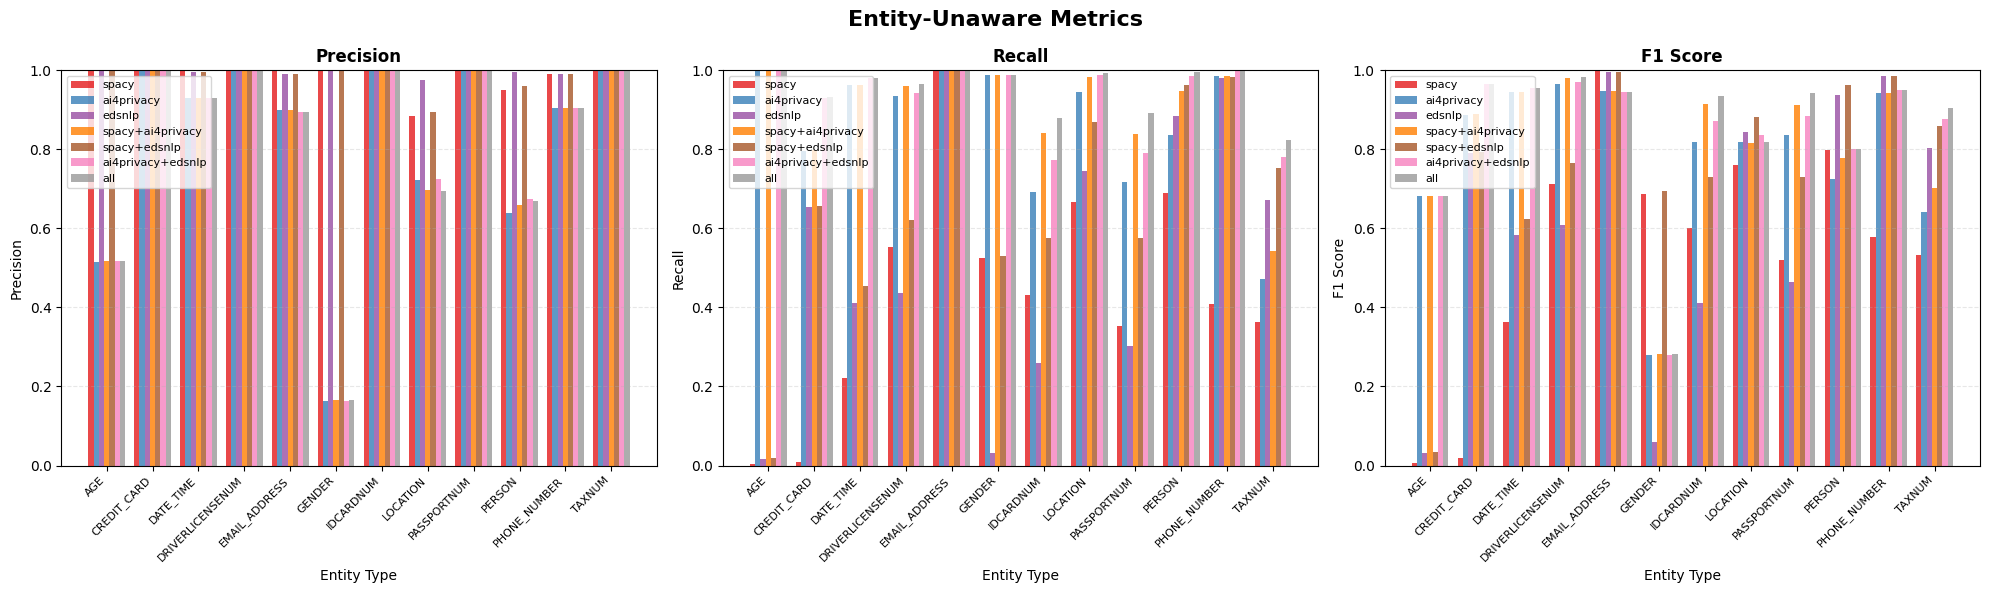

In [15]:
# Plot entity-unaware metrics
fig2 = plot_metrics(df_unaware, 'Entity-Unaware Metrics', figsize=(20, 6))
plt.show()
